<a href="https://colab.research.google.com/github/hridibazaman03/220142_KMeans_image/blob/main/220142_KMeans_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
!git clone https://github.com/hridibazaman03/220142_KMeans_image.git
%cd 220142_KMeans_image

Cloning into '220142_KMeans_image'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 28 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 2.30 MiB | 13.87 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/220142_KMeans_image/220142_KMeans_image/220142_KMeans_image/220142_KMeans_image/220142_KMeans_image/220142_KMeans_image


In [78]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib
import os

In [79]:
img = Image.open("dataset/Standard_image.jpg")

img = img.resize((300, 300))

img = np.array(img)

print("Image shape:", img.shape)

Image shape: (300, 300, 3)


In [80]:
pixels = img.reshape(-1, 3)

print("Pixels shape:", pixels.shape)

Pixels shape: (90000, 3)


In [81]:
scaler = StandardScaler()
pixels_scaled = scaler.fit_transform(pixels)

print("Scaled shape:", pixels_scaled.shape)

Scaled shape: (90000, 3)


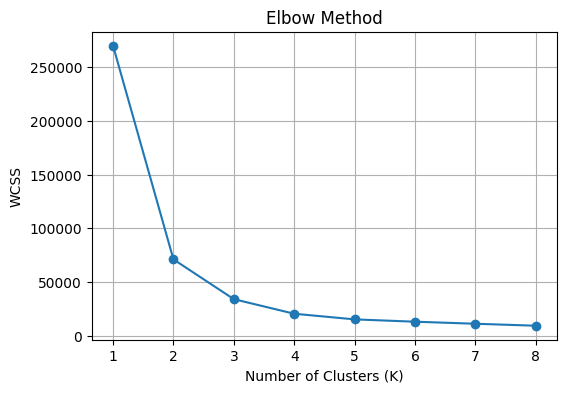

In [82]:
wcss = []

K_range = range(1, 9)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(pixels_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid()
plt.show()

In [83]:
optimal_k = 8

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixels_scaled)

In [84]:
os.makedirs("model", exist_ok=True)

joblib.dump(kmeans, "model/kmeans_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


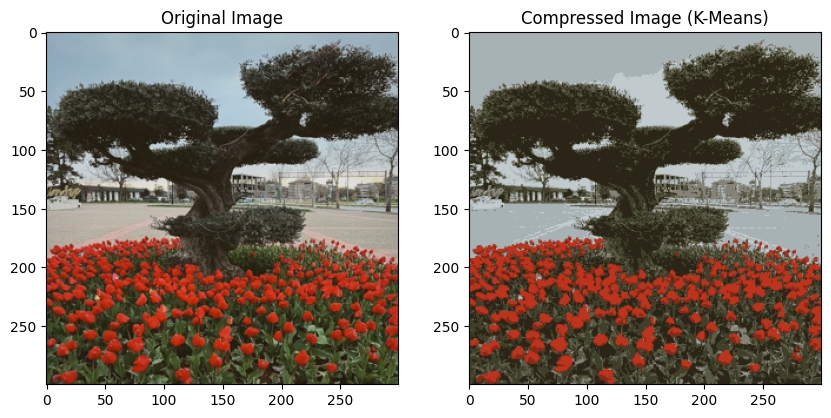

In [85]:
compressed_pixels = scaler.inverse_transform(
    kmeans.cluster_centers_[labels]
)

compressed_img = compressed_pixels.reshape(img.shape)

compressed_img = np.clip(compressed_img, 0, 255).astype(np.uint8)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img)

plt.subplot(1,2,2)
plt.title("Compressed Image (K-Means)")
plt.imshow(compressed_img)

plt.show()

In [86]:
custom_img = Image.open("dataset/Custom_photo.jpg")
custom_img = custom_img.resize((300,300))

custom_img = np.array(custom_img)
custom_pixels = custom_img.reshape(-1,3)

In [87]:
custom_scaled = scaler.transform(custom_pixels)
custom_labels = kmeans.predict(custom_scaled)

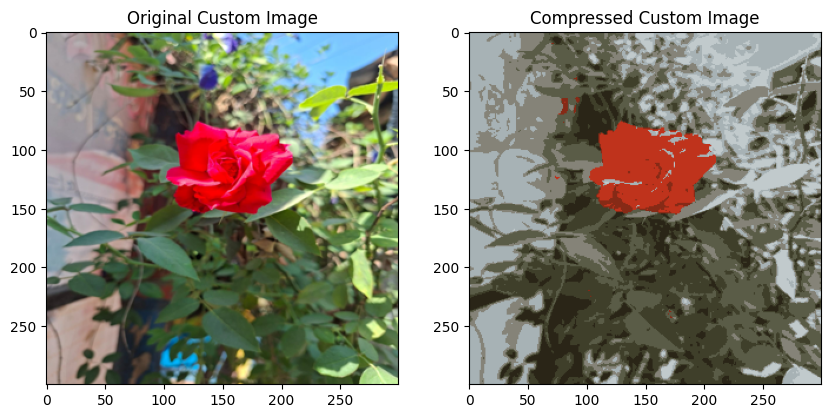

In [88]:
compressed_custom_pixels = scaler.inverse_transform(
    kmeans.cluster_centers_[custom_labels]
)

compressed_custom_img = compressed_custom_pixels.reshape(custom_img.shape)

compressed_custom_img = np.clip(compressed_custom_img, 0, 255).astype(np.uint8)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Custom Image")
plt.imshow(custom_img)

plt.subplot(1,2,2)
plt.title("Compressed Custom Image")
plt.imshow(compressed_custom_img)

plt.show()

In [89]:
custom_scaled = scaler.transform(custom_pixels)

custom_labels = kmeans.predict(custom_scaled)

df_custom = pd.DataFrame(custom_pixels, columns=["R","G","B"])
df_custom["Cluster_ID"] = custom_labels

df_custom.head(10)

,R,G,B,Cluster_ID
0,178,177,176,0
1,173,171,172,0
2,164,162,166,0
3,158,156,161,0
4,161,157,160,0
5,165,159,161,0
6,169,160,161,0
7,171,162,161,0
8,167,163,163,0
9,165,161,162,0


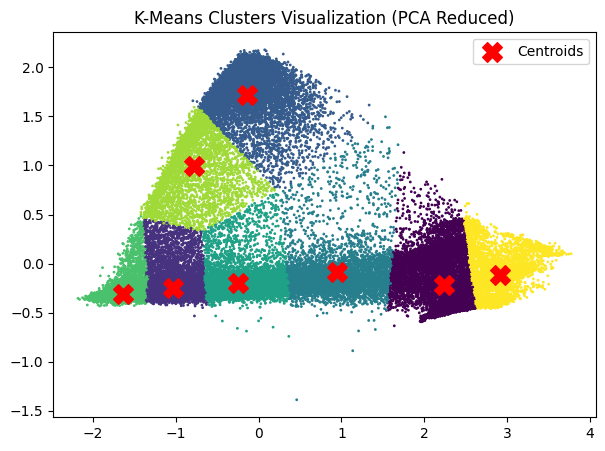

In [90]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pixels_2d = pca.fit_transform(pixels_scaled)

centroids_2d = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(7,5))

plt.scatter(
    pixels_2d[:,0],
    pixels_2d[:,1],
    c=labels,
    cmap='viridis',
    s=1
)

plt.scatter(
    centroids_2d[:,0],
    centroids_2d[:,1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.title("K-Means Clusters Visualization (PCA Reduced)")
plt.legend()
plt.show()

The K-Means algorithm divides the image into distinct colour clusters based on similarity in RGB values. Each cluster centroid represents a dominant colour present in the image such as dark tones, mid-range colours or bright highlights. These clusters help reduce the overall colour complexity of the image while preserving its visual structure and appearance.